# Stillwater SewerTris Example

This notebook implements the Stillwater SewerTris workflow using the refactored `sewertris` package in `src/sewertris`. It starts from the Stillwater domain shapefile, fills the domain with tetromino-style urban blocks, generates roads and topography, builds a sanitary sewer network, assigns land use and design flows, exports an EPA-SWMM model, defines BWF, GWI, and RDII inputs, and saves decomposed flow outputs for analysis.

The notebook is organized around the twelve key SewerTris model implementation steps:

1. Urban Domain Definition: Defines the spatial modeling boundary using a vector polygon or raster mask and establishes the sewer outlet location.

2. Tetris Block Definition: Specifies modular tetromino building blocks (I, L, T, S, Z shapes) that form the geometric basis of the synthetic urban layout.

3. Stochastic Tetris Completion: Populates the domain using randomized block placement to generate heterogeneous but coherent urban configurations.

4. Road Network Extraction: Derives a synthetic road network from block boundaries, ensuring topological consistency with urban structure.

5. Land-Use Assignment: Assigns residential, commercial, industrial, public, and recreational land uses using rule-based or user-defined allocation strategies.

6. Synthetic DEM Generation: Creates a hydraulically consistent Digital Elevation Model (DEM) enforcing global drainage toward the outlet.

7. Sewer Network Generation: Constructs a gravity-driven, tree-structured sewer network aligned with roads and embedded within the DEM.

8. Sewer Flow Predesign: Computes baseline peak discharges combining Dry-Weather Flow (DWF), Groundwater Infiltration (GWI), and Rainfall-Derived Inflow and Infiltration (RDII).

9. Pipe Sizing and Hydraulic Properties: Assigns pipe diameters, roughness, and invert elevations using Manning-based design principles.

10. Dynamic Flow Input Definition: Specifies temporally resolved DWF, GWI, and RDII inputs, including rainfall forcing and spatial heterogeneity options.

11. EPA-SWMM Simulation: Performs unsteady hydraulic routing and enables component tagging (RAIN and DRY) for flow separation analysis.

12. Flow Output Decomposition: Extracts and decomposes total flows into DWF, RDII, and residual GWI components for benchmarking and diagnostics.


## Setup: Import Libraries

This cell imports the scientific Python stack and adds the repository `src` directory to `sys.path`, so the notebook uses the refactored `sewertris` package directly.


In [82]:
import os
import random
import sys
from pathlib import Path

import geopandas as gpd
import numpy as np
import rasterio

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "sewertris").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXAMPLES_DIR = PROJECT_ROOT / "examples"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import sewertris as sp


## 1. Urban Domain Definition

Defines the spatial modeling boundary using the Stillwater domain shapefile in `input/domain_mask.shp`. The shapefile is rasterized into a model domain mask while preserving geospatial metadata for later export.


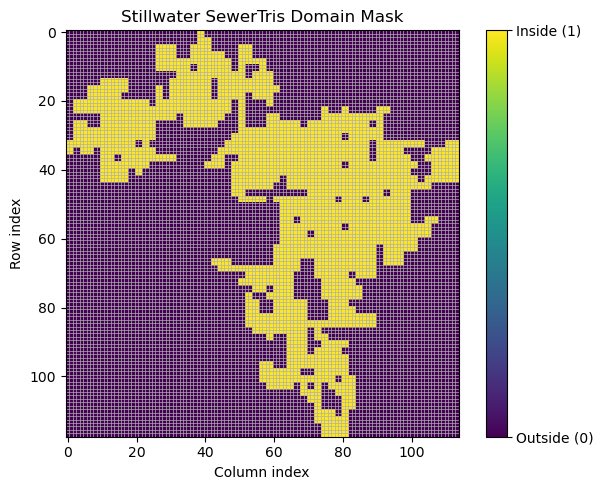

In [83]:
# --- Parameters ---
min_width = 100  # meters
use_shapefile = True
shapefile_path = Path("input/domain_mask.shp")
if not shapefile_path.exists():
    shapefile_path = PROJECT_ROOT / "examples" / "input" / "domain_mask.shp"

if use_shapefile:
    gdf_in = gpd.read_file(shapefile_path)
    cell_size = sp.meters_to_crs_units(min_width, gdf_in.crs)
    domain_mask, grid_meta = sp.build_domain_mask_from_shapefile(
        shapefile_path,
        cell_size_m=cell_size,
    )
else:
    domain_mask = np.array([
        [0,0,0,0,0,1,1,1,0,0,1,1,1,1,1,0,0],
        [0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,0,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
    ])
    grid_meta = dict(
        crs_out="EPSG:3857",
        origin_x=0,
        origin_y=0,
        cell_w=min_width,
        cell_h=min_width,
        rows=domain_mask.shape[0],
        cols=domain_mask.shape[1],
        flip_y=False,
    )

sp.plot_domain_mask(domain_mask, title="Stillwater SewerTris Domain Mask")


## 2. Tetris Block Definition

Specifies modular tetromino building blocks (I, L, T, S, Z shapes) that form the geometric basis of the synthetic urban layout.


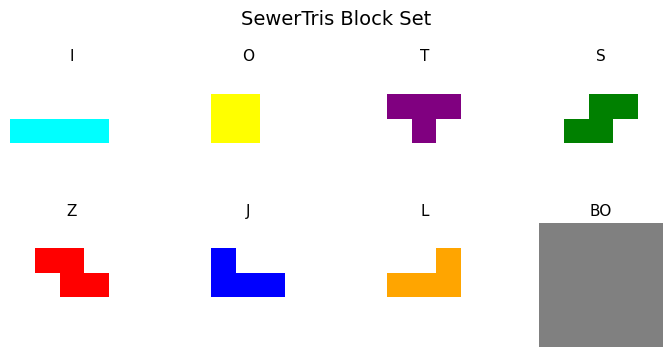

In [84]:
# Tetromino definitions (all rotations)
tetrominoes = {
    'I': [np.array([[1,1,1,1]]), np.array([[1],[1],[1],[1]])],
    'O': [np.array([[1,1],[1,1]])],
    'T': [np.array([[1,1,1],[0,1,0]]), np.array([[0,1],[1,1],[0,1]]), np.array([[0,1,0],[1,1,1]]), np.array([[1,0],[1,1],[1,0]])],
    'S': [np.array([[0,1,1],[1,1,0]]), np.array([[1,0],[1,1],[0,1]])],
    'Z': [np.array([[1,1,0],[0,1,1]]), np.array([[0,1],[1,1],[1,0]])],
    'J': [np.array([[1,0,0],[1,1,1]]), np.array([[1,1],[1,0],[1,0]]), np.array([[1,1,1],[0,0,1]]), np.array([[0,1],[0,1],[1,1]])],
    'L': [np.array([[0,0,1],[1,1,1]]), np.array([[1,0],[1,0],[1,1]]), np.array([[1,1,1],[1,0,0]]), np.array([[1,1],[0,1],[0,1]])],
    'BO': [np.array([[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1]])],
}

# Assign a color to each tetromino
tetromino_colors = {
    'I': 'cyan',
    'O': 'yellow',
    'T': 'purple',
    'S': 'green',
    'Z': 'red',
    'J': 'blue',
    'L': 'orange',
    'BO': 'grey',
}

sp.plot_tetromino_set(tetrominoes, tetromino_colors, ncols=4)


## 3. Stochastic Tetris Completion

Populates the Stillwater domain using randomized block placement to generate a coherent synthetic urban configuration, then exports the resulting blocks as geospatial polygons.


Total blocks: 1524
✅ Exported 1523 figures to /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/City_2.shp


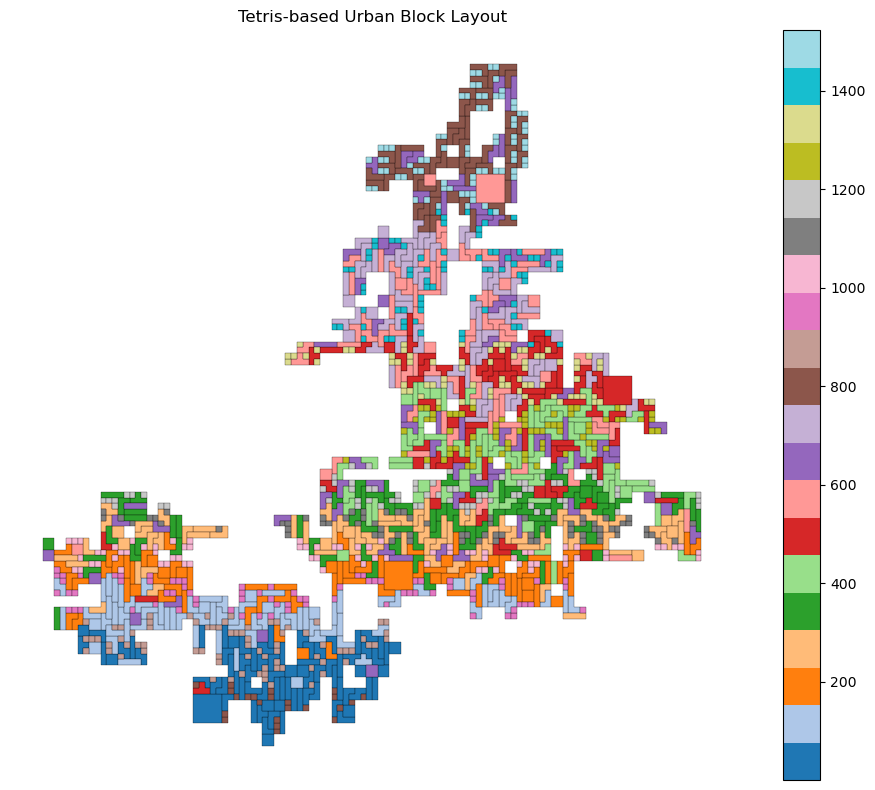

In [85]:
layout_seed = 1000 # Seed 1002 is good for testing bad convergance in previous method
random.seed(layout_seed)
np.random.seed(layout_seed)

# Fill the domain with tetrominoes and blocks
filled_board, id_type_map, block_id = sp.fill_domain_with_tetrominoes_and_blocks(
    domain_mask,
    tetrominoes,
)
print("Total blocks:", len(np.unique(filled_board)))

# Export the filled board to a shapefile in the same coordinate space as the domain shapefile
output_folder = EXAMPLES_DIR / "output_example_2"
os.makedirs(output_folder, exist_ok=True)
output_shapefile = os.path.join(output_folder, "City_2.shp")

sp.export_individual_figures_to_shapefile_georeferenced(
    filled_board,
    output_shapefile,
    grid_meta,
    id_to_type_map=id_type_map,
)

sp.plot_filled_board_shapefile(output_shapefile)


## 4. Road Network Extraction

Derives a synthetic road network from block boundaries, ensuring topological consistency with the generated urban structure.


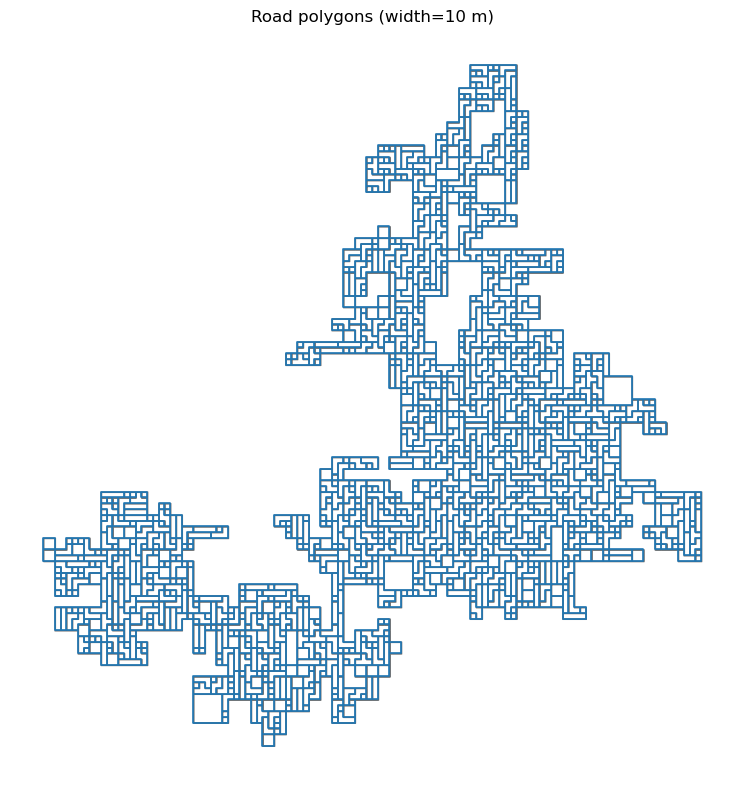

In [86]:
# Generate road network from blocks
road_width = 10  # meters
road_lines, road_buffer, crs = sp.generate_road_network_from_blocks(
    blocks_path=output_shapefile,
    road_width=road_width,
    simplify_tol=0.5,
)

gpd.GeoDataFrame(geometry=[road_lines], crs=crs).to_file(
    os.path.join(output_folder, "road_centerlines.shp")
)
gpd.GeoDataFrame(geometry=[road_buffer], crs=crs).to_file(
    os.path.join(output_folder, "road_polygons.shp")
)

sp.plot_roads(
    road_lines=road_lines,
    road_buffer=road_buffer,
    crs=crs,
    title=f"Road polygons (width={road_width} m)",
)


## 5. Land-Use Assignment

Assigns residential, commercial, industrial, public, and recreational land uses using compact rule-based allocation.


✅ Exported to /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/City_2.shp


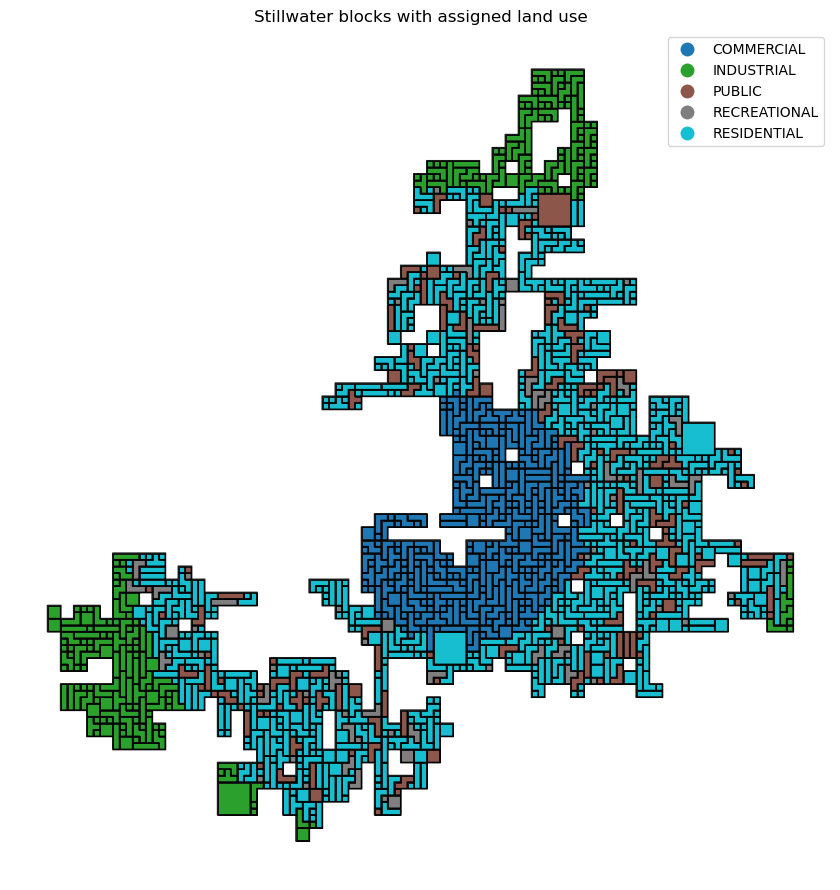

In [87]:
# Cut, label blocks and assign land use
blocks_path = output_shapefile
roads_path = os.path.join(output_folder, "road_polygons.shp")
output_path = os.path.join(output_folder, "City_2.shp")

blocks, road_network, crs = sp.load_blocks_and_roads(blocks_path, roads_path)
blocks = sp.cut_blocks(blocks, road_network)
blocks = sp.assign_land_use_compact(blocks)
gdf = sp.export_to_shapefile(blocks, crs, output_path)

roads_gdf = gpd.read_file(roads_path)
if roads_gdf.crs != gdf.crs:
    roads_gdf = roads_gdf.to_crs(gdf.crs)

sp.plot_blocks_landuse(
    blocks_gdf=gdf,
    roads_gdf=roads_gdf,
    landuse_col="land_use",
    title="Stillwater blocks with assigned land use",
    savepath=os.path.join(output_folder, "blocks_landuse.png"),
)


## 6. Synthetic DEM Generation

Creates a hydraulically consistent Digital Elevation Model (DEM) enforcing global drainage toward the configured outlet direction.


[OK] Boundary lines written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/road_boundary_lines.shp
[OK] Outer shell polygon(s) written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/road_outer_shell.shp
Original boundary CRS: EPSG:32614
Original roads CRS: EPSG:32614

Boundary extent:
X range: 667166.00 to 678576.00
Y range: 3994829.67 to 4006639.67
Boundary CRS: EPSG:32614
Boundary bounds: [ 667165.9958307  3994829.67323194  678575.9958307  4006639.67323194]
Grid shape: (1202, 1162)
Grid extent:
  X: 667060.00 to 678680.00
  Y: 3994720.00 to 4006740.00
Creating mask...
Processing row 0 of 1202
Processing row 100 of 1202
Processing row 200 of 1202
Processing row 300 of 1202
Processing row 400 of 1202
Processing row 500 of 1202
Processing row 600 of 1202
Processing row 700 of 1202
Processing row 800 of 1202
Processing row 900 of 1202
Processing row 1000 of 1202
Processing row 1100 of 1202
Processing row 1200 of 1202
Outlet cell: (1110, 591)
Co

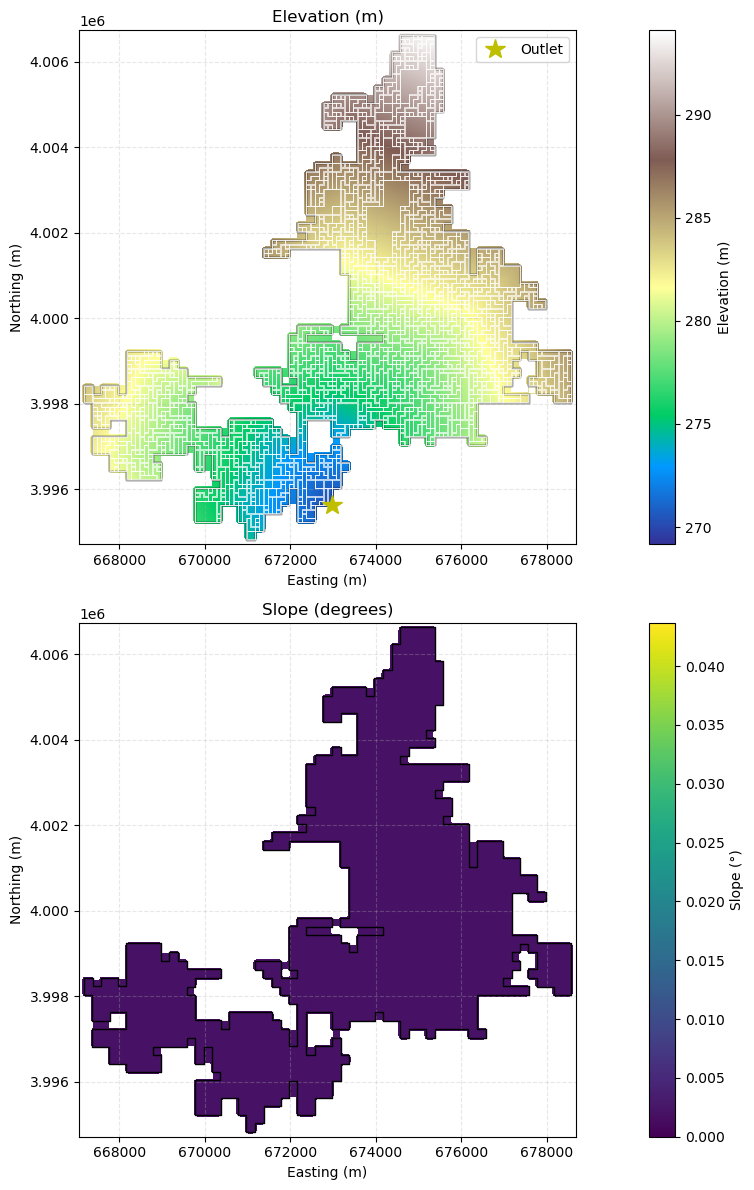


Terrain Statistics:
Elevation range: 269.17m - 294.09m
Mean elevation: 281.10m
Mean slope: 0.00°
Max slope: 0.04°

Drainage Statistics:
Points with proper drainage: 500309.0 out of 533617 (93.8%)
Using CRS: EPSG:32614
Topography successfully generated and saved to /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/generated_topography.tif
DEM resolution: 10 m
Elevation range: 270 m - 290 m
Output CRS: EPSG:32614
Grid extent:
  X: 667060.00 to 678680.00
  Y: 4006740.00 to 3994720.00


In [88]:
# Extract road boundaries
roads_path = os.path.join(output_folder, "road_polygons.shp")
sp.extract_boundary(
    roads_path,
    out_boundary_lines=os.path.join(output_folder, "road_boundary_lines.shp"),
    out_outer_shell_polygon=os.path.join(output_folder, "road_outer_shell.shp"),
    keep_holes=False,
)

config = sp.TopographyConfig(
    min_elevation=270,
    max_elevation=290,
    cell_size=10,
    outlet_direction='S',
    smoothing_factor=1,
)

boundary_path = os.path.join(output_folder, "road_outer_shell.shp")
roads_path = os.path.join(output_folder, "road_polygons.shp")

if not os.path.exists(boundary_path) or not os.path.exists(roads_path):
    raise FileNotFoundError("Input shapefiles not found. Please check the file paths.")

try:
    elevation, xx, yy, mask = sp.generate_topography(boundary_path, roads_path, config)

    boundary_gdf = gpd.read_file(boundary_path)
    input_crs = boundary_gdf.crs

    if input_crs is None:
        print("Warning: Input CRS is None, defaulting to UTM Zone 14N (EPSG:32614)")
        input_crs = "EPSG:32614"

    print(f"Using CRS: {input_crs}")

    output_path = os.path.join(output_folder, "generated_topography.tif")
    transform = rasterio.transform.from_bounds(
        west=xx[0,0],
        south=yy[-1,0],
        east=xx[0,-1],
        north=yy[0,0],
        width=elevation.shape[1],
        height=elevation.shape[0],
    )

    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=elevation.shape[0],
        width=elevation.shape[1],
        count=1,
        dtype=elevation.dtype,
        crs=input_crs,
        transform=transform,
        nodata=np.nan,
    ) as dst:
        dst.write(elevation, 1)

    print(f"Topography successfully generated and saved to {output_path}")
    print(f"DEM resolution: {config.cell_size} m")
    print(f"Elevation range: {config.min_elevation} m - {config.max_elevation} m")
    print(f"Output CRS: {input_crs}")
    print("Grid extent:")
    print(f"  X: {xx[0,0]:.2f} to {xx[0,-1]:.2f}")
    print(f"  Y: {yy[0,0]:.2f} to {yy[-1,0]:.2f}")

except Exception as e:
    print(f"Error generating topography: {str(e)}")
    raise


## 7. Sewer Network Generation

Constructs a gravity-driven, tree-structured sewer network aligned with roads and embedded within the DEM.


✅ Extracted 3473 manholes from road centerlines.
✅ Manholes exported to /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/manholes.shp

Path Statistics:
Head: MH1914  →  Target: MH2191
Segments: 113
Total length: 15200.0 m
Total drop: 24.82 m
Avg slope: 0.152%
⚠️ Some manholes could not be connected while preserving constraints.
✅ Generated 1214 secondary pipes.
✅ Cleaned: 0 secondary pipes removed.
Main outlet ID: MH2191
Total manholes: 3473
Nodes already touched by main+secondary: 1328
Manholes missing outlet pipe: 2145
First 20 missing: ['MH001', 'MH002', 'MH003', 'MH005', 'MH006', 'MH007', 'MH011', 'MH013', 'MH014', 'MH016', 'MH018', 'MH019', 'MH020', 'MH021', 'MH025', 'MH026', 'MH027', 'MH028', 'MH031', 'MH032']
Duplicate sources: []
📊 Initial missing outlet pipes: 2145
Iteration 1: start=MH033, status=committed, chain_len=6, remaining=2139
Iteration 2: start=MH039, status=committed, chain_len=6, remaining=2133
Iteration 3: start=MH045, status=committed, chain_len=2

/Users/kevinblanco/Documents/Sewertris/src/sewertris/sewer_network.py:2583: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstream'
  ogr_write(


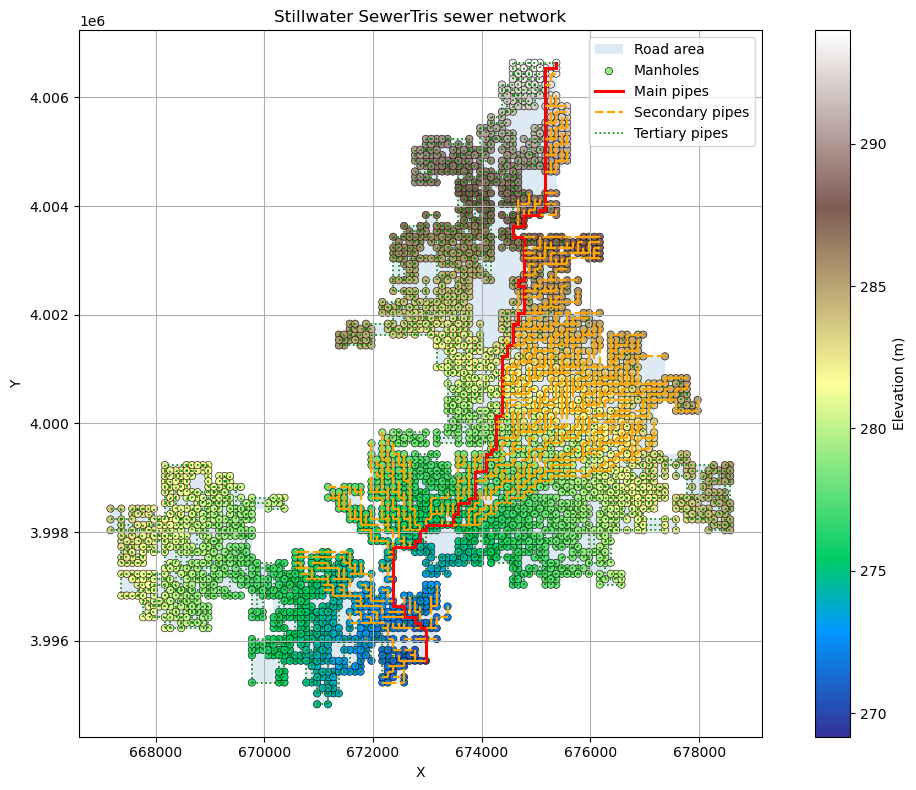

In [89]:
road_axes_path = os.path.join(output_folder, "road_centerlines.shp")
dem_path = os.path.join(output_folder, "generated_topography.tif")
manholes = sp.extract_manholes_from_lines(road_axes_path, dem_path)
sp.export_manholes_to_shapefile(
    manholes,
    os.path.join(output_folder, "manholes.shp"),
    crs=gpd.read_file(road_axes_path).crs,
)

road_buffer = road_lines.buffer(road_width * 0.6)

segments, path_info, graph_data = sp.generate_main_sewer_path_optimized(
    manholes=manholes,
    road_buffer=road_buffer,
    block_size=min_width * 2,
    slope_tolerance=-0.01,
    min_pipe_length=5.0,
    prefer_slope=0.5,
    return_graph_data=True,
)

main_path = path_info["segments"]

secondary_pipes, secondary_attrs = sp.generate_secondary_pipes_optimized(
    manholes=manholes,
    main_path=main_path,
    road_buffer=road_lines.buffer(road_width * 0.6),
    block_size=min_width * 2,
    slope_tolerance=0.00,
    prefer_slope=0.5,
    return_attrs=True,
)

secondary_pipes_clean = sp.remove_secondary_pipes_overlapping_main_optimized(
    manholes=manholes,
    secondary_pipes=secondary_pipes,
    main_pipes=main_path,
)

network_status = sp.build_current_network_status(
    manholes=manholes,
    main_path=main_path,
    secondary_pipes=secondary_pipes_clean,
)

print("Main outlet ID:", network_status["main_outlet_id"])
print("Total manholes:", len(network_status["all_ids"]))
print("Nodes already touched by main+secondary:", len(network_status["nodes_in_network"]))
print("Manholes missing outlet pipe:", len(network_status["missing_outlet_ids"]))
print("First 20 missing:", network_status["missing_outlet_ids"][:20])
print("Duplicate sources:", network_status["duplicate_sources"][:20])

tertiary_pipes, tertiary_unconnected, tertiary_attrs = sp.generate_tertiary_pipes_backtracking_stop_at_each_manhole(
    manholes=manholes,
    main_path=main_path,
    secondary_pipes=secondary_pipes_clean,
    road_buffer=road_lines.buffer(road_width * 0.6),
    city_boundary=os.path.join(output_folder, "road_outer_shell.shp"),
    block_size=min_width * 10,
    neighbor_radius_factor=1.5,
    min_pipe_length=1e-3,
    point_on_line_tol=0.01,
    return_attrs=True,
    max_search_depth=300,
)

main_attrs = sp.build_main_attrs_from_path_info(path_info)

gdf_pipes = sp.export_pipes_to_shapefile_2(
    pipes_main=main_path,
    pipes_sec=secondary_pipes_clean,
    pipes_ter=tertiary_pipes,
    manholes=manholes,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    crs=crs,
    main_attrs=main_attrs,
    secondary_attrs=secondary_attrs,
    tertiary_attrs=tertiary_attrs,
)

print("Sewer network generation complete.")

sp.plot_sewer_network_all(
    manholes=manholes,
    main_pipes=main_path,
    secondary_pipes=secondary_pipes_clean,
    tertiary_pipes=tertiary_pipes,
    unresolved=tertiary_unconnected,
    road_buffer=road_buffer,
    title="Stillwater SewerTris sewer network",
)


### Step 7 Continued: Embed the Sewer Network in the DEM

The DEM is adjusted along pipe alignments so the generated sewer network maintains positive gravity slopes.


Modifying topography to follow sewer network...
⚠️ Raster check: 3035 pipes have a local slope < Smin (e.g., idx=3006, slope=-0.002398).
Wrote: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/generated_topography.tif
Updated elevations for 3473/3473 manholes. Wrote: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/manholes.shp


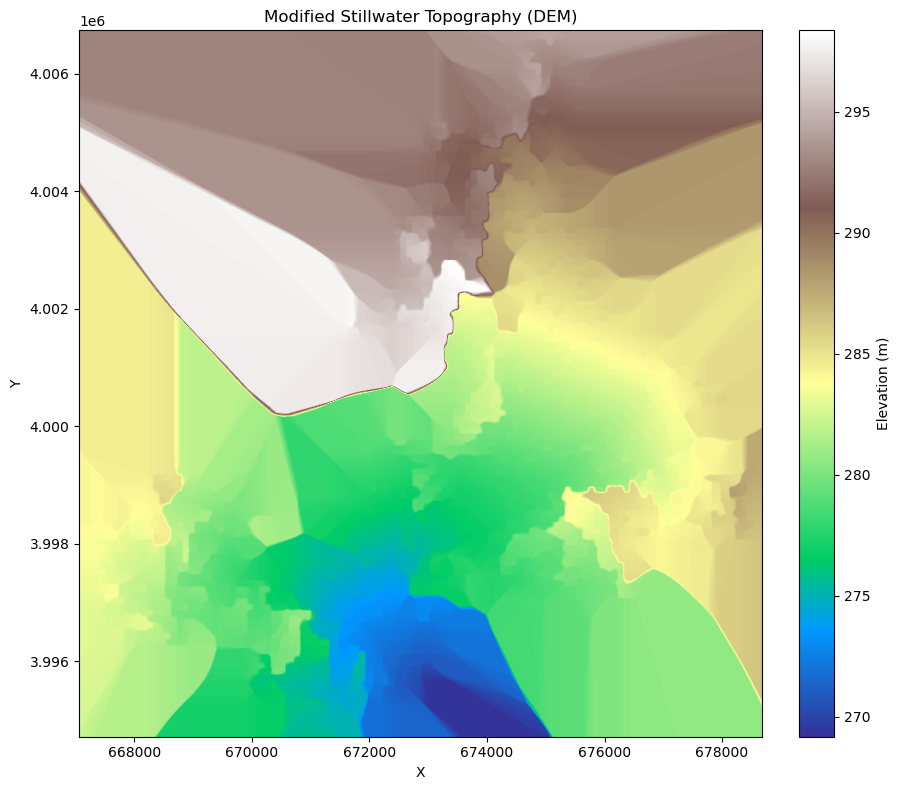

In [90]:
# Modify topography to follow the sewer network
print("Modifying topography to follow sewer network...")

dem_path = os.path.join(output_folder, "generated_topography.tif")
sewer_path = os.path.join(output_folder, "sewer_pipes.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
output_path = os.path.join(output_folder, "generated_topography.tif")

out_path = sp.build_dem_with_guaranteed_positive_slopes_idw(
    dem_path=dem_path,
    pipes_path=sewer_path,
    manholes_path=manholes_path,
    output_path=output_path,
    upstream_field="upstream_m",
    downstream_field="downstream",
    manhole_id_field="id",
    manhole_elev_field="elevation",
    type_field="type",
    tier_order=("main", "secondary", "tertiary"),
    Smin=0.001,
    densify_step_m=None,
    along_pipe_weight=2,
    idw_power=2.0,
    idw_k=12,
    idw_tile=1024,
    centerline_writeback=True,
    verify_on_raster=True,
)
print("Wrote:", out_path)

sp.update_manhole_elevations_from_dem(
    dem_path=out_path,
    manholes_path=manholes_path,
    output_path=None,
    overwrite=True,
    sampling="nearest",
)

sp.plot_dem_tif(output_path, title="Modified Stillwater Topography (DEM)", hillshade=False)


## 8. Sewer Flow Predesign

Computes baseline peak discharges combining Dry-Weather Flow (DWF), Groundwater Infiltration (GWI), and Rainfall-Derived Inflow and Infiltration (RDII).


In [91]:
blocks_path = os.path.join(output_folder, "City_2.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
pipes_path = os.path.join(output_folder, "sewer_pipes.shp")
topography_path = os.path.join(output_folder, "generated_topography.tif")

# For each land use category:
# - density is in people per hectare [people/ha]
# - demand is in liters per person per day [L/person/day]
LAND_USE_INFO = {
    'RESIDENTIAL': {
        'density': 60,
        'demand': 100,
    },
    'COMMERCIAL': {
        'density': 50,
        'demand': 60,
    },
    'INDUSTRIAL': {
        'density': 25,
        'demand': 150,
    },
    'PUBLIC': {
        'density': 20,
        'demand': 100,
    },
    'RECREATIONAL': {
        'density': 10,
        'demand': 40,
    },
}

sp.delineate_afferent_areas_and_baseflow(
    blocks_path=blocks_path,
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    topo_path=topography_path,
    output_path=os.path.join(output_folder, "sewer_subcatchments.shp"),
    land_use_info=LAND_USE_INFO,
)

subcatchments_path = os.path.join(output_folder, "sewer_subcatchments.shp")

sp.assign_flow_to_pipes_fast(
    pipes_path=pipes_path,
    subcatchments_path=subcatchments_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
)

pipes = gpd.read_file(os.path.join(output_folder, "sewer_pipes.shp"))
peak_flow, pf = sp.british_columbia_peaking_factor(pipes["cumulative"])
pipes["peaking_factor_bc"] = pf
pipes["peak_flow_lps_bc"] = peak_flow
pipes.to_file(os.path.join(output_folder, "sewer_pipes.shp"))
print("Peak flows added using BC method.")

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.compute_gwi_cumulative(
    pipes_path=pipes_path,
    gwi_factor_ls_per_m=0.0002,
    out_path=os.path.join(output_folder, "sewer_pipes.shp"),
    id_field="pipe_id",
    up_field="upstream_m",
    down_field="downstream",
    length_field=None,
    target_crs_m="EPSG:3857",
)

sp.compute_rdii_and_accumulate(
    pipes_path=pipes_path,
    subcatch_path=subcatchments_path,
    rdii_factor_ls_per_m2=0.00002,
    pipe_id_field="pipe_id",
    up_field="upstream_m",
    down_field="downstream",
    sub_pipe_field="pipe_id",
    target_crs_m="EPSG:3857",
    out_pipes=os.path.join(output_folder, "sewer_pipes.shp"),
    out_subcatch=os.path.join(output_folder, "sewer_subcatchments.shp"),
)

sp.add_predesign_flow(
    pipes_path=os.path.join(output_folder, "sewer_pipes.shp"),
    out_path=os.path.join(output_folder, "sewer_pipes.shp"),
)


/Users/kevinblanco/Documents/Sewertris/src/sewertris/hydrology.py:70: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  output.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'base_flow_lps' to 'base_flow_'
  ogr_write(
/Users/kevinblanco/Documents/Sewertris/src/sewertris/hydrology.py:263: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  pipes.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstre_1'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'own_flow_lps' to 'own_flow_l'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/

✅ Sub-catchments saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_subcatchments.shp
✅ Updated pipe file saved: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_pipes.shp
Peak flows added using BC method.


/Users/kevinblanco/Documents/Sewertris/src/sewertris/hydrology.py:374: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(out_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstre_2'
  ogr_write(
/Users/kevinblanco/Documents/Sewertris/src/sewertris/hydrology.py:477: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstre_3'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'own_rdii_ls' to 'own_rdii_l'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: Runt

,pipe_id,upstream_m,downstream,type,dist_m,slope,cost,downstre_1,own_flow_l,cumulative,...,length_m,own_gwi_ls,cum_gwi_ls,downstre_3,own_rdii_l,cum_rdii_l,geometry,downstream_m,predesign_ls,predesign_
0,P00000,MH1914,MH2550,main,100.0,0.002000,100.0,MH2550,0.024197,0.121564,...,100.0,0.02,0.10,MH2550,0.111500,0.560168,"LINESTRING (675370.996 4006634.673, 675370.996...",MH2550,1.146425,1.146425
1,P00001,MH2550,MH2967,main,200.0,0.000828,200.0,MH2967,0.048828,0.170392,...,200.0,0.04,0.14,MH2967,0.225000,0.785168,"LINESTRING (675370.996 4006534.673, 675170.996...",MH2967,1.606737,1.606737
2,P00002,MH2967,MH2464,main,100.0,0.002000,100.0,MH2464,0.070617,0.241010,...,100.0,0.02,0.16,MH2464,0.325405,1.110573,"LINESTRING (675170.996 4006534.673, 675170.996...",MH2464,2.234611,2.234611
3,P00003,MH2464,MH2623,main,200.0,0.002000,200.0,MH2623,0.067500,0.308510,...,200.0,0.04,0.20,MH2623,0.311042,1.421614,"LINESTRING (675170.996 4006434.673, 675170.996...",MH2623,2.855654,2.855654
4,P00004,MH2623,MH2117,main,100.0,0.002000,100.0,MH2117,0.035753,0.554438,...,100.0,0.02,0.30,MH2117,0.164750,2.554850,"LINESTRING (675170.996 4006234.673, 675170.996...",MH2117,5.072601,5.072601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3467,P03467,MH088,MH738,tertiary,100.0,0.000828,100.0,MH738,0.046123,0.046123,...,100.0,0.02,0.02,MH738,0.252500,0.252500,"LINESTRING (675370.996 3998934.673, 675370.996...",MH738,0.456991,0.456991
3468,P03468,MH1108,MH1620,tertiary,100.0,-0.001531,100.0,MH1620,0.016840,0.093200,...,100.0,0.02,0.04,MH1620,0.048500,0.268417,"LINESTRING (675770.996 3999634.673, 675770.996...",MH1620,0.681218,0.681218
3469,P03469,MH2194,MH1077,tertiary,100.0,-0.001297,100.0,MH1077,0.107581,0.107581,...,100.0,0.02,0.02,MH1077,0.309833,0.309833,"LINESTRING (675570.996 3999534.673, 675670.996...",MH1077,0.760157,0.760157
3470,P03470,MH1261,MH1782,tertiary,100.0,-0.000828,100.0,MH1782,0.066927,0.066927,...,100.0,0.02,0.02,MH1782,0.192750,0.192750,"LINESTRING (675770.996 3999434.673, 675770.996...",MH1782,0.480458,0.480458


## 9. Pipe Sizing and Hydraulic Properties

Assigns pipe slopes, diameters, roughness values, materials, and invert elevations using design rules compatible with Manning-based hydraulic sizing.


/Users/kevinblanco/Documents/Sewertris/src/sewertris/design.py:82: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  pipes.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstre_5'
  ogr_write(


✅ Pipe slopes assigned and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_pipes.shp


/Users/kevinblanco/Documents/Sewertris/src/sewertris/design.py:217: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstre_6'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'calc_diameter_mm' to 'calc_diame'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'diameter_mm' to 'diameter_m'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'diameter_m' to 'diameter_1'
  ogr_write(


✅ Materials and diameters assigned and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_pipes.shp


/Users/kevinblanco/Documents/Sewertris/src/sewertris/design.py:310: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  pipes.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstre_7'
  ogr_write(
/Users/kevinblanco/Documents/Sewertris/src/sewertris/design.py:351: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  pipes_clean.to_file(output_pipes_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstre_8'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'diameter_mm' to 'diameter_2'
  ogr_write(


✅ Invert elevations assigned and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_pipes.shp
✅ Pipes saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_pipes.shp
✅ Manholes saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/manholes.shp


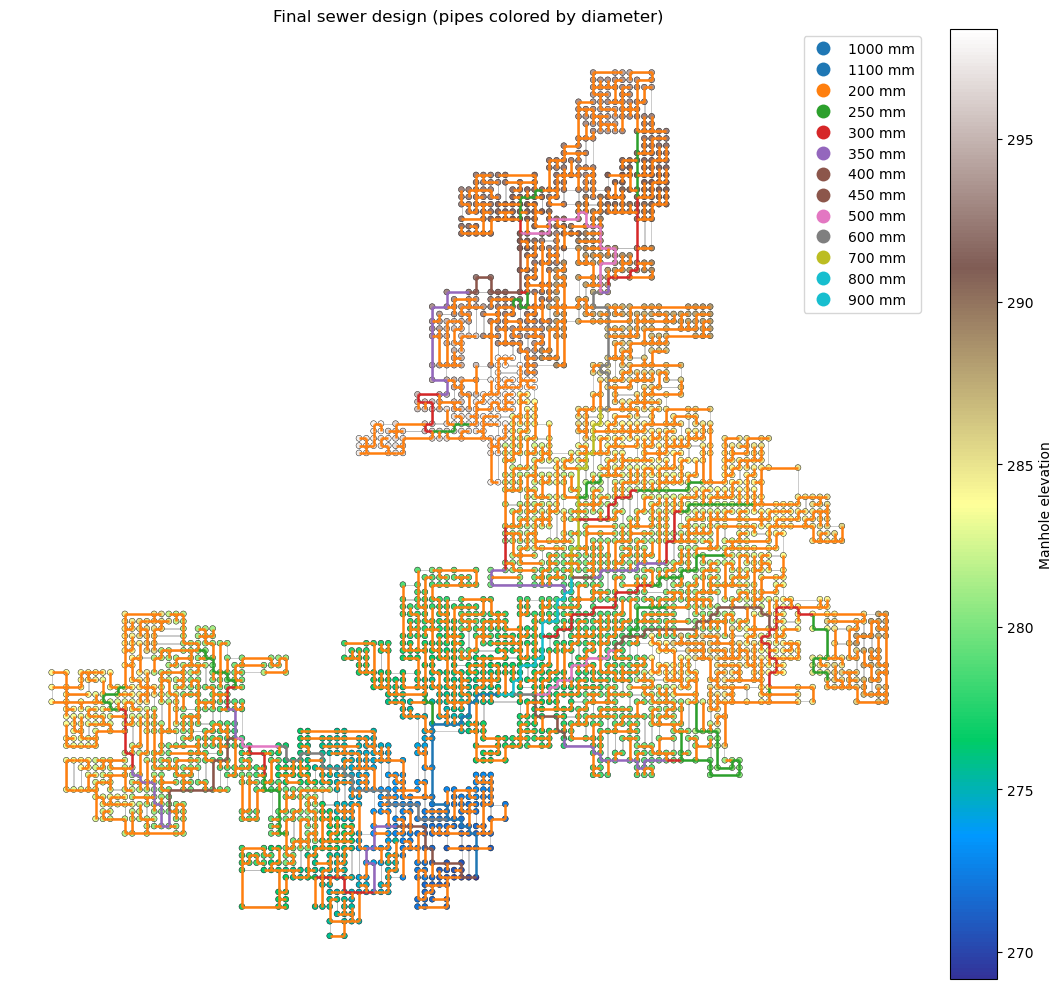

In [92]:
pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.assign_pipe_slopes(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    minimum_slope=0.005,
)

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.assign_material_diameter_to_pipes(
    pipes_path=pipes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    material_fractions={"PVC": 0.6, "CONCRETE": 0.3, "HDPE": 0.1},
    n_by_material={"PVC": 0.011, "CONCRETE": 0.013, "HDPE": 0.012},
    standard_diameters_mm=[200, 250, 300, 350, 400, 450, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000],
    minimum_diameter_mm=200,
)

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.assign_invert_elevations(
    pipes_path=pipes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    min_cover=1.4,
    min_slope=0.005,
    manhole_drop=0.05,
)

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

sp.preprocess_pipes_and_manholes(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_pipes_path=os.path.join(output_folder, "sewer_pipes.shp"),
    output_manholes_path=os.path.join(output_folder, "manholes.shp"),
)

final_pipes = os.path.join(output_folder, "sewer_pipes.shp")
final_mhs = os.path.join(output_folder, "manholes.shp")

sp.plot_final_design_color_by_diameter(
    pipes_path=final_pipes,
    manholes_path=final_mhs,
    blocks_path=blocks_path,
    diameter_field="diameter_m",
    manhole_color_field="elevation",
    linewidth=1.8,
)


## 10. Dynamic Flow Input Definition

Specifies temporally resolved BWF/DWF, GWI, and RDII inputs, including daily/hourly patterns, baseline infiltration, rainfall forcing, and subcatchment routing. The model is run after each major input layer so the response can be checked incrementally.


In [98]:
# Export to SWMM INP format
# Ten days simulation
routing_step = "0:00:10"  # 10 seconds
START_DATE = "01/01/2025"
END_DATE = "01/10/2025"

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
options = {
    "FLOW_UNITS": "LPS",
    "INFILTRATION": "CURVE_NUMBER",
    "FLOW_ROUTING": "KINWAVE",
    "LINK_OFFSETS": "DEPTH",
    "MIN_SLOPE": "0",
    "ALLOW_PONDING": "NO",
    "SKIP_STEADY_STATE": "NO",
    "START_DATE": START_DATE,
    "START_TIME": "00:00:00",
    "REPORT_START_DATE": START_DATE,
    "REPORT_START_TIME": "00:00:00",
    "END_DATE": END_DATE,
    "END_TIME": "00:00:00",
    "SWEEP_START": "01/01",
    "SWEEP_END": "12/31",
    "DRY_DAYS": "0",
    "REPORT_STEP": "00:15:00",
    "WET_STEP": "00:00:10",
    "DRY_STEP": "00:00:10",
    "ROUTING_STEP": routing_step,
    "RULE_STEP": "00:00:00",
    "INERTIAL_DAMPING": "PARTIAL",
    "NORMAL_FLOW_LIMITED": "BOTH",
    "FORCE_MAIN_EQUATION": "D-W",
    "VARIABLE_STEP": "0.75",
    "LENGTHENING_STEP": "0",
    "MIN_SURFAREA": "1.167",
    "MAX_TRIALS": "8",
    "HEAD_TOLERANCE": "0.0015",
    "SYS_FLOW_TOL": "5",
    "LAT_FLOW_TOL": "5",
    "MINIMUM_STEP": "0.5",
    "THREADS": "1",
}

sp.export_swmm_inp(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    options_dict=options,
)


✅ SWMM .inp file written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_model.inp


In [99]:
# BWF/DWF patterns
SWMM_INPUT_FILE = os.path.join(output_folder, "sewer_model.inp")

hourly = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.4838, 0.8014,
    1.1337, 1.3239, 1.3321, 1.2512, 1.1900, 1.1703,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.3362, 1.3175, 1.1978, 0.9890, 0.7576,
]

daily_vals = [1.0, 1.0, 1.0, 1.0, 1.0, 1.1, 1.2]

monthly_vals = [
    0.90, 0.95, 1.00, 1.05,
    1.10, 1.10, 1.05, 1.00,
    0.95, 0.90, 0.90, 0.90,
]

fairfax_weekend = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.3568, 0.4068,
    0.6068, 0.7068, 0.8014, 1.1337, 1.3239, 1.3321,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.1362, 1.0175, 0.8978, 0.8090, 0.7576,
]

sp.assign_all_dwf_patterns(
    inp_path=SWMM_INPUT_FILE,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    hourly_id="1",
    hourly_values=hourly,
    daily_id="2",
    daily_values=daily_vals,
    monthly_id="3",
    monthly_values=monthly_vals,
    weekend_id="4",
    weekend_values=fairfax_weekend,
)

print("SWMM INP file with BWF/DWF patterns created.")




✅ Updated [DWF] with patterns "1" "2" "3" "4"
✅ Rewrote [PATTERNS] with HOURLY, DAILY, MONTHLY, WEEKEND
   Output saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_model.inp
SWMM INP file with BWF/DWF patterns created.


✅ INFLOWS section created using coefficient 0.0001. File saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_model.inp


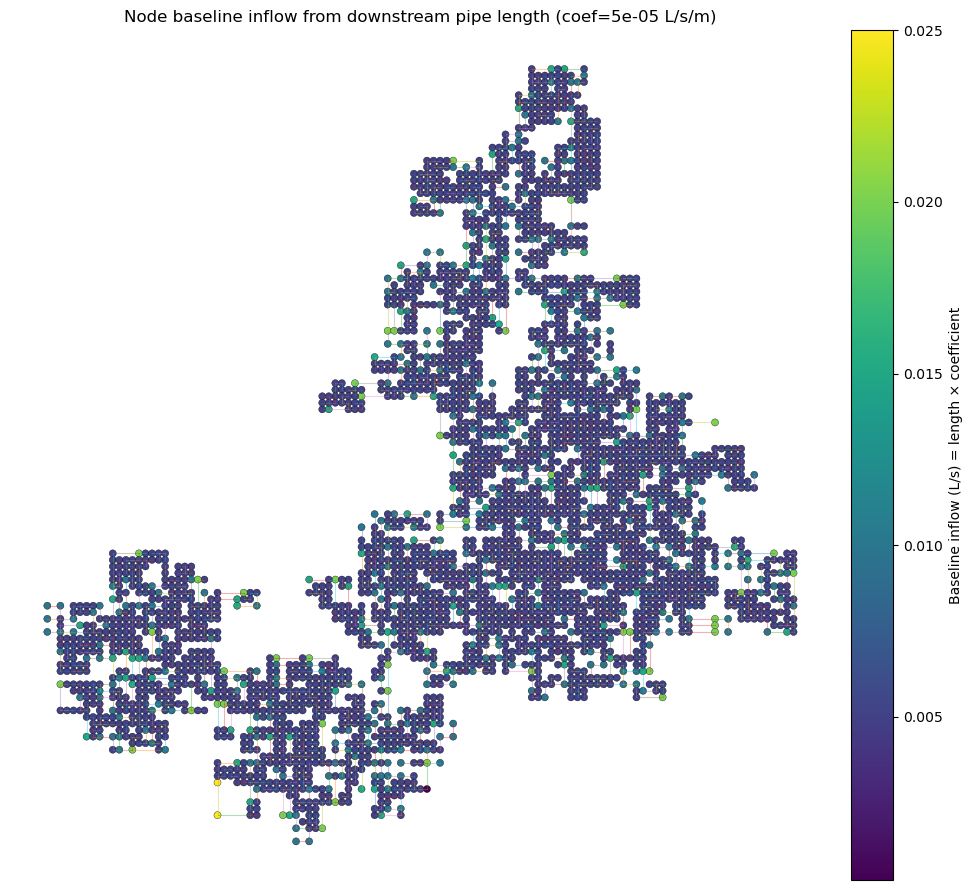

Nodes plotted: 3473
Inflow range: 0.0003 to 0.0250 L/s


In [100]:
# GWI
inp_file = os.path.join(output_folder, "sewer_model.inp")

gwi_coefficient = 0.00005
sp.assign_inflow_from_pipe_length(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    coefficient=gwi_coefficient,
)

sp.plot_inflow_from_pipe_length(
    inp_path=os.path.join(output_folder, "sewer_model.inp"),
    coefficient=gwi_coefficient,
)




In [101]:
# RDII
inp_file = os.path.join(output_folder, "sewer_model.inp")
rainfall_seed = 42 # Seed 44 is good for testing bad convergance in previous method


# rainfall_data = sp.generate_clustered_rainfall_timeseries(
#     start_date=f"{START_DATE} 00:00",
#     end_date=f"{END_DATE} 00:00",
#     timestep_minutes=15,
#     avg_annual_precip_mm=600,
#     wet_season_months=[4, 5, 6, 9, 10, 11],
#     dry_wet_ratio=0.2,
#     storm_prob=0.1,
#     storm_duration_range=(1, 6),
#     random_seed=rainfall_seed,
#     preview_date=f"{START_DATE}",
# )

rainfall_data=[
    ('1/2/2025', '00:00', 0.0), ('1/2/2025', '00:30', 0.138), ('1/2/2025', '01:00', 0.201),
    ('1/2/2025', '01:30', 0.195), ('1/2/2025', '02:00', 0.171), ('1/2/2025', '02:30', 0.153),
    ('1/2/2025', '03:00', 0.147), ('1/2/2025', '03:30', 0.156), ('1/2/2025', '04:00', 0.171),
    ('1/2/2025', '04:30', 0.189), ('1/2/2025', '05:00', 0.21), ('1/2/2025', '05:30', 0.228),
    ('1/2/2025', '06:00', 0.246), ('1/2/2025', '06:30', 0.258), ('1/2/2025', '07:00', 0.27),
    ('1/2/2025', '07:30', 0.279), ('1/2/2025', '08:00', 0.288), ('1/2/2025', '08:30', 0.297),
    ('1/2/2025', '09:00', 0.309), ('1/2/2025', '09:30', 0.321), ('1/2/2025', '10:00', 0.339),
    ('1/2/2025', '10:30', 0.357), ('1/2/2025', '11:00', 0.387), ('1/2/2025', '11:30', 0.42),
    ('1/2/2025', '12:00', 0.456), ('1/2/2025', '12:30', 0.501), ('1/2/2025', '13:00', 0.555),
    ('1/2/2025', '13:30', 0.609), ('1/2/2025', '14:00', 0.669), ('1/2/2025', '14:30', 0.732),
    ('1/2/2025', '15:00', 0.795), ('1/2/2025', '15:30', 0.861), ('1/2/2025', '16:00', 0.918),
    ('1/2/2025', '16:30', 0.972), ('1/2/2025', '17:00', 1.023), ('1/2/2025', '17:30', 1.065),
    ('1/2/2025', '18:00', 1.104), ('1/2/2025', '18:30', 1.137), ('1/2/2025', '19:00', 1.167),
    ('1/2/2025', '19:30', 1.197), ('1/2/2025', '20:00', 1.23), ('1/2/2025', '20:30', 1.26),
    ('1/2/2025', '21:00', 1.287), ('1/2/2025', '21:30', 1.302), ('1/2/2025', '22:00', 1.293),
    ('1/2/2025', '22:30', 1.251), ('1/2/2025', '23:00', 1.155), ('1/2/2025', '23:30', 0.984),
    ('1/3/2025', '00:00', 0.747), ('1/3/2025', '00:30', 0.0), ('1/3/2025', '01:00', 0.0),
]

subcatchments_path = os.path.join(output_folder, "sewer_subcatchments.shp")

sp.add_subcatchment_data_to_inp(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    subcatchments_path=subcatchments_path,
    raingage_id="1",
    raingage_coords=(500, 500),
    timeseries=rainfall_data,
    interval='0:30',
    n_imperv=0.011,
    n_perv=0.15,
    s_imperv=0.0,
    s_perv=0.0,
    pct_zero=0,
    route_to="OUTLET",
    pct_routed="",
    infiltration_params=(1, 0.5, 7, "", ""),
    imperv_pct=2,
    width=100,
    slope=0.005,
    curblen=0,
)


✅ SWMM .inp file updated with subcatchments and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_model.inp


## 11. EPA-SWMM Simulation

Adds pollutant/component tags to the SWMM input and runs PySWMM-based flow separation on the outlet pipe.


In [102]:
inp_file = os.path.join(output_folder, "sewer_model.inp")

sp.auto_add_pollutants_to_inp_fixed(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
)

inp_path = os.path.join(output_folder, "sewer_model.inp")

df = sp.get_flow_components_from_node_pyswmm(
    inp_path=inp_path,
    link_id="P_OUTLET",
)


✅ Tagged inp written (uses CONCEN) -> /Users/kevinblanco/Documents/Sewertris/examples/output_example_2/sewer_model.inp


## 12. Flow Output Decomposition

Extracts and decomposes total flows into DWF, RDII, and residual GWI components for benchmarking and diagnostics, then saves the flow dataset for later analysis.


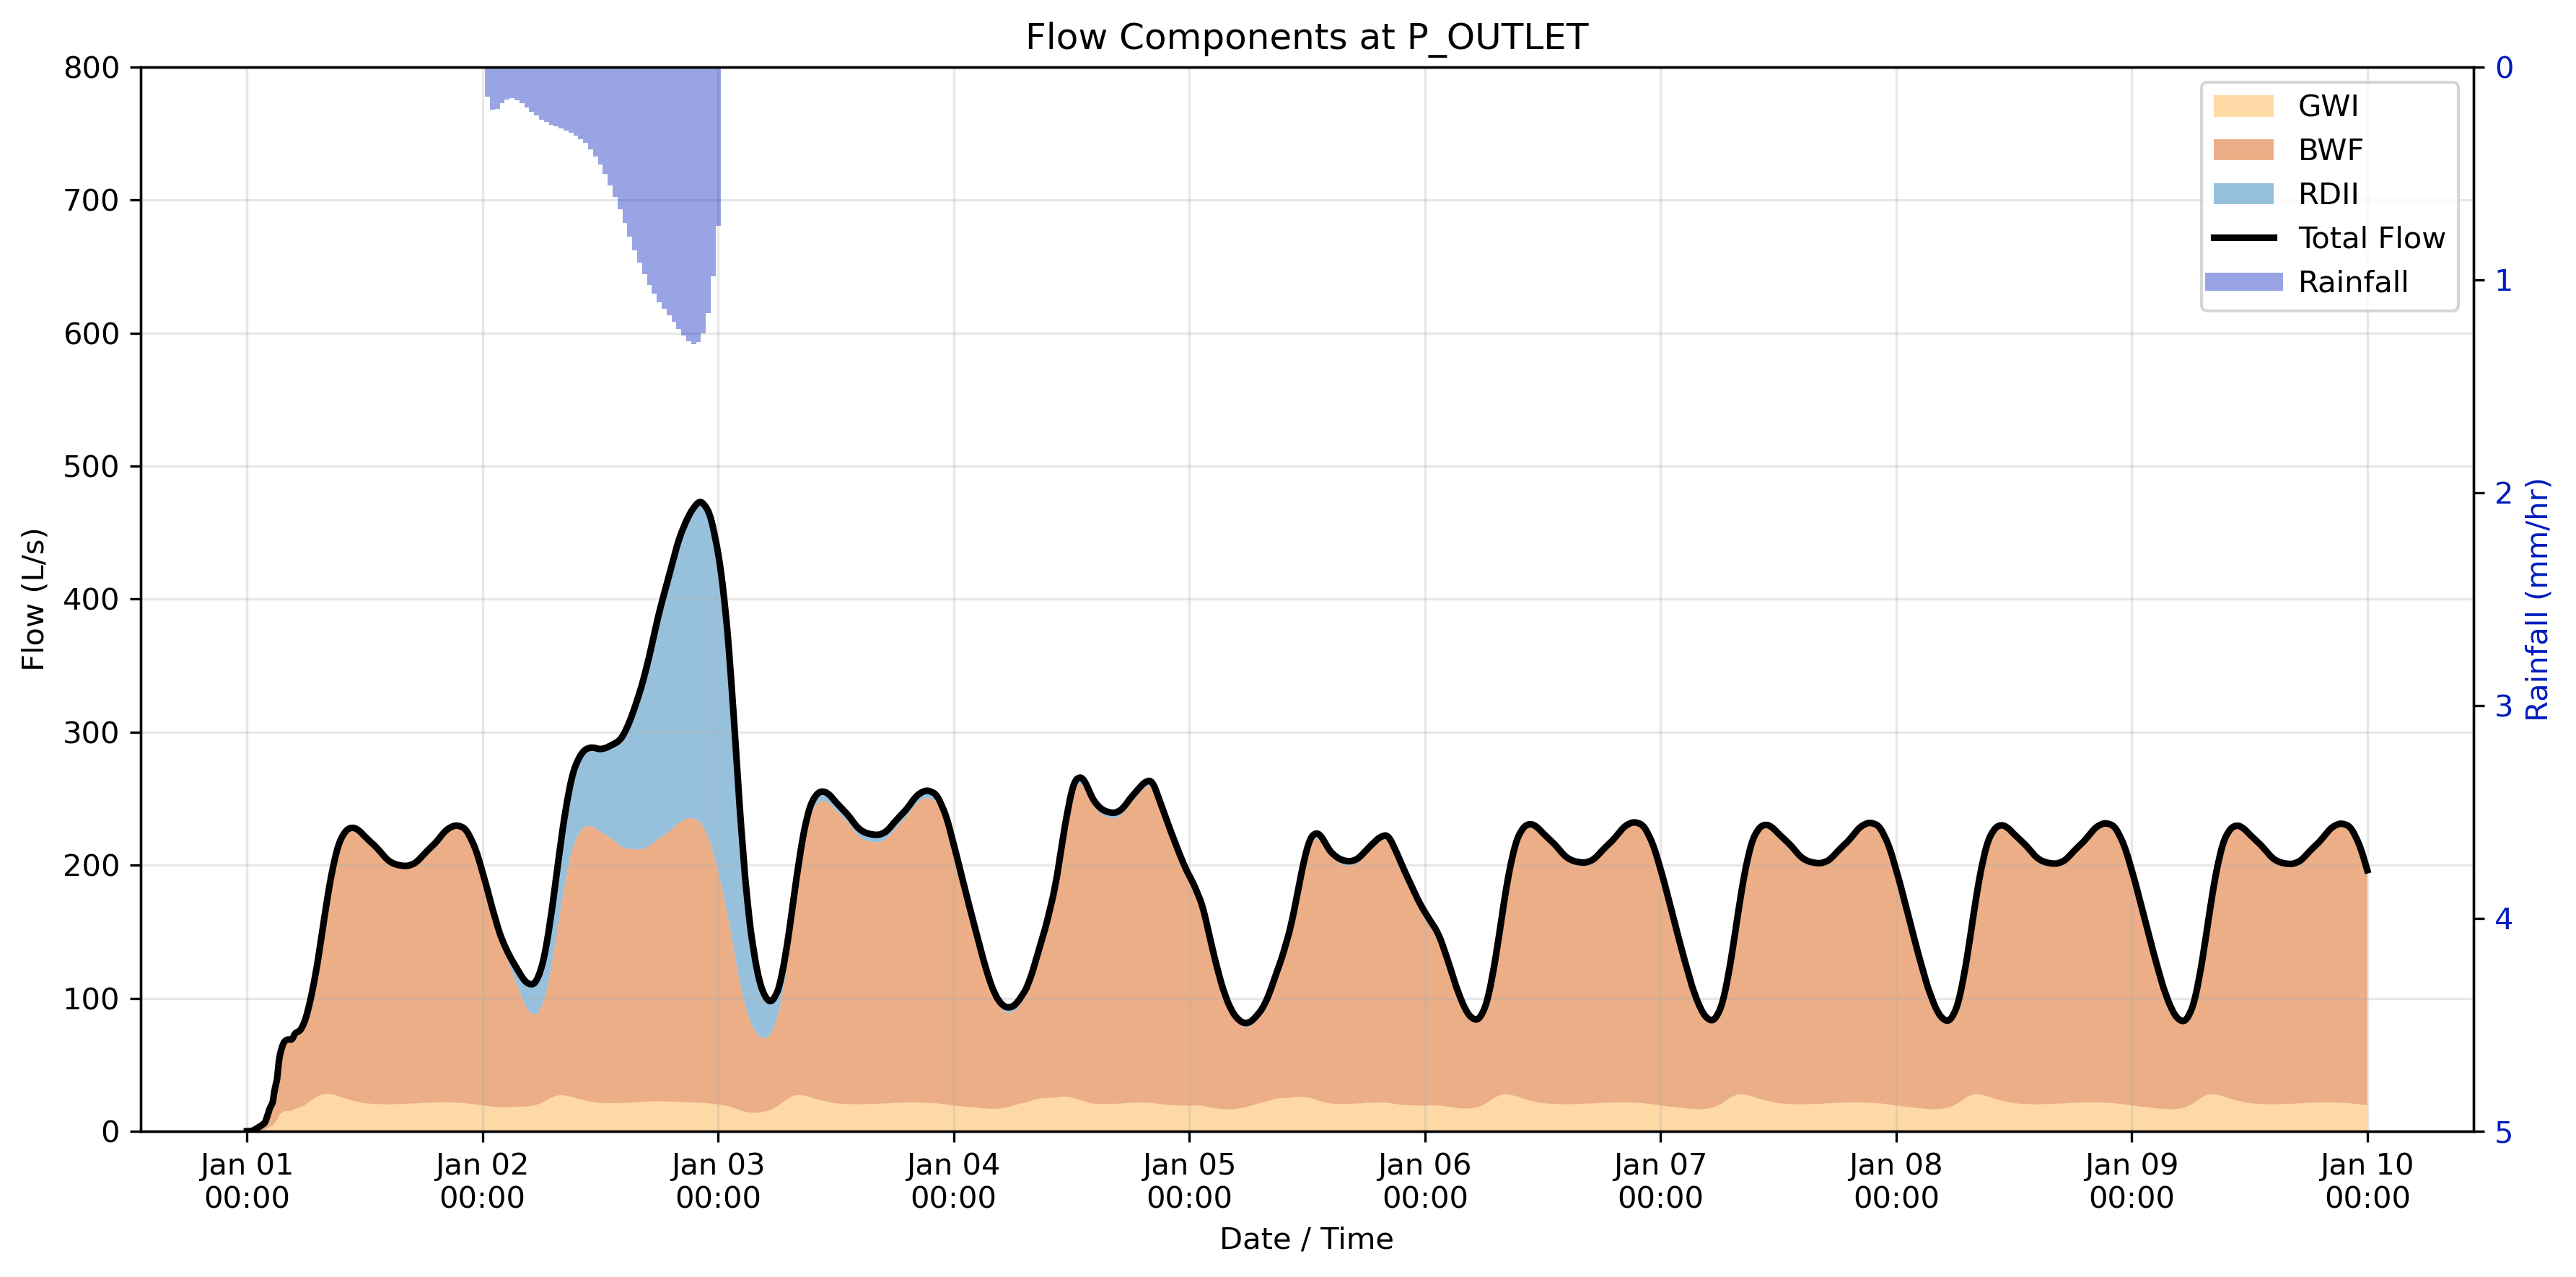

Saved as flows.nc


In [103]:
sp.plot_flow_components_v2(
    df,
    rain=rainfall_data,
    start=f"{START_DATE} 00:00:00",
    end=f"{END_DATE} 00:00:00",
    flow_units="L/s",
    stack_components=True,
    flow_min=0,
    flow_max=800,
    rain_min=0,
    rain_max=5
)

flows_for_export = df.set_index("Datetime") if "Datetime" in df.columns else df
flows_ds = flows_for_export.to_xarray()
flows_ds.to_netcdf(os.path.join(output_folder, "flows.nc"))
print("Saved as flows.nc")
